In [1]:
import os
import numpy as np
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
# from engine import train_one_epoch, evaluate
# import utils
# import transforms as T
import albumentations as A
import cv2
import time
from albumentations.pytorch.transforms import ToTensorV2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from  sklearn.model_selection import KFold
import random
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
def get_model_bbox(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=True)
    
    # get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [3]:
!nvidia-smi

Fri Oct 31 13:15:45 2025       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.147.05   Driver Version: 525.147.05   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-SXM2...  Off  | 00000000:15:00.0 Off |                    0 |
| N/A   37C    P0    52W / 300W |   1177MiB / 32768MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  Tesla V100-SXM2...  Off  | 00000000:16:00.0 Off |                    0 |
| N/A   

In [4]:
model = get_model_bbox(1)

/home/reshetnikov/miniconda3/envs/mmyolo/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/reshetnikov/miniconda3/envs/mmyolo/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
model.roi_heads

RoIHeads(
  (box_roi_pool): MultiScaleRoIAlign(featmap_names=['0', '1', '2', '3'], output_size=(7, 7), sampling_ratio=2)
  (box_head): TwoMLPHead(
    (fc6): Linear(in_features=12544, out_features=1024, bias=True)
    (fc7): Linear(in_features=1024, out_features=1024, bias=True)
  )
  (box_predictor): FastRCNNPredictor(
    (cls_score): Linear(in_features=1024, out_features=1, bias=True)
    (bbox_pred): Linear(in_features=1024, out_features=4, bias=True)
  )
)

In [6]:
class CraterDataset(object):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        # load all image files, sorting them to
        # ensure that they are aligned
        self.imgs = list(sorted(os.listdir(os.path.join(self.root, "images"))))
        self.annots = list(sorted(os.listdir(os.path.join(self.root, "labels"))))
        self.classes = ['Background','Crater']
        
    # Converts boundry box formats, this version assumes single class only!
    def convert_box_cord(self,bboxs, format_from, format_to, img_shape):
        if format_from == 'normxywh':
            if format_to == 'xyminmax':
                xw = bboxs[:, (1, 3)] * img_shape[1]
                yh = bboxs[:, (2, 4)] * img_shape[0]
                xmin = xw[:, 0] - xw[:, 1] / 2
                xmax = xw[:, 0] + xw[:, 1] / 2
                ymin = yh[:, 0] - yh[:, 1] / 2
                ymax = yh[:, 0] + yh[:, 1] / 2
                coords_converted = np.column_stack((xmin, ymin, xmax, ymax))

        return coords_converted

    def __getitem__(self, idx):
        # load images and boxes
        img_path = os.path.join(self.root, "images", self.imgs[idx])
        annot_path = os.path.join(self.root, "labels", self.annots[idx])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
        img= img/255.0

        # retrieve bbox list and format to required type,
        # if annotation file is empty, fill dummy box with label 0
        if os.path.getsize(annot_path) != 0:
            bboxs = np.loadtxt(annot_path, ndmin=2)
            bboxs = self.convert_box_cord(bboxs, 'normxywh', 'xyminmax', img.shape)
            num_objs = len(bboxs)
            bboxs = torch.as_tensor(bboxs, dtype=torch.float32)
            # there is only one class
            labels = torch.ones((num_objs,), dtype=torch.int64)
            # suppose all instances are not crowd
            iscrowd = torch.zeros((num_objs,), dtype=torch.int64)
        else:
            bboxs = torch.as_tensor([[0, 0, 640, 640]], dtype=torch.float32)
            labels = torch.zeros((1,), dtype=torch.int64)
            iscrowd = torch.zeros((1,), dtype=torch.int64)

        area = (bboxs[:, 3] - bboxs[:, 1]) * (bboxs[:, 2] - bboxs[:, 0])
        image_id = torch.tensor([idx])

        target = {}
        target["boxes"] = bboxs
        target["labels"] = labels
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            sample = self.transforms(image=img,
                                     bboxes=target['boxes'],
                                     labels=labels)
        img = sample['image']
        target['boxes'] = torch.tensor(sample['bboxes'])
        target['labels'] = torch.tensor(sample['labels'])
        if target['boxes'].ndim == 1:
            target['boxes'] = torch.as_tensor([[0, 0, 640, 640]], dtype=torch.float32)
            target['labels'] = torch.zeros((1,), dtype=torch.int64)
        return img, target

    def __len__(self):
        return len(self.imgs)

In [7]:
def get_transform(train):
    if train:
        return A.Compose([
            # A.Flip(p=0.5),
            # A.RandomResizedCrop(height=640,width=640,p=0.4),
            # # A.Perspective(p=0.4),
            # A.Rotate(p=0.5),
            # # A.Transpose(p=0.3),
            ToTensorV2(p=1.0)],
            bbox_params=A.BboxParams(format='pascal_voc',min_visibility=0.4, label_fields=['labels']))
    else:
        return A.Compose([ToTensorV2(p=1.0)],
                         bbox_params=A.BboxParams(format='pascal_voc', min_visibility=0.5, label_fields=['labels']))

In [8]:
def plot_img_bbox(img, target):
    # plot the image and bboxes
    # Bounding boxes are defined as follows: x-min y-min width height
    fig, a = plt.subplots(1, 1)
    fig.set_size_inches(5, 5)
    a.imshow(img.permute((1,2,0)))
    for box in (target['boxes']):
        x, y, width, height = box[0], box[1], box[2] - box[0], box[3] - box[1]
        rect = patches.Rectangle((x, y),
                                 width, height,
                                 edgecolor='b',
                                 facecolor='none',
                                 clip_on=False)
        a.annotate('Crater', (x,y-20), color='blue', weight='bold',
                   fontsize=10, ha='left', va='top')

        # Draw the bounding box on top of the image
        a.add_patch(rect)
    plt.show()

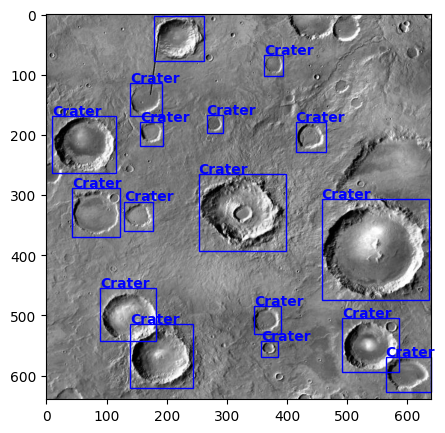

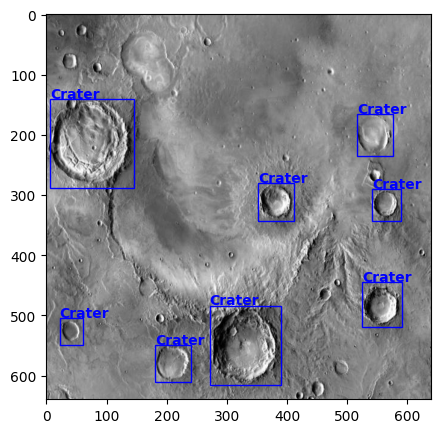

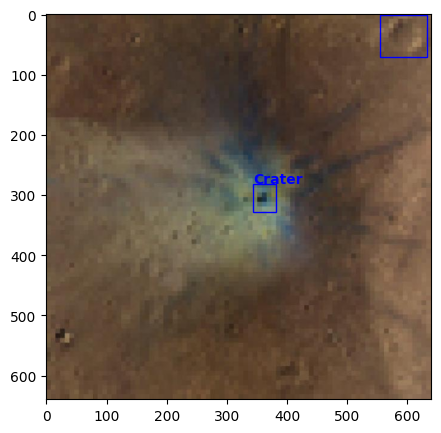

In [9]:
dataset = CraterDataset('./craters_task/craters/train', get_transform(train=True))
# Prints an example of image with annotations
for i in random.sample(range(1, 25), 3):
    img, target = dataset[i]
    plot_img_bbox(img, target)

In [10]:
torch.cuda.is_available()

True

In [11]:
import torch.distributed as dist

In [12]:
def reduce_dict(input_dict, average=True):
    """
    Args:
        input_dict (dict): all the values will be reduced
        average (bool): whether to do average or sum
    Reduce the values in the dictionary from all processes so that all processes
    have the averaged results. Returns a dict with the same fields as
    input_dict, after reduction.
    """
    world_size = 1
    if world_size < 2:
        return input_dict
    with torch.inference_mode():
        names = []
        values = []
        # sort the keys so that they are consistent across processes
        for k in sorted(input_dict.keys()):
            names.append(k)
            values.append(input_dict[k])
        values = torch.stack(values, dim=0)
        dist.all_reduce(values)
        if average:
            values /= world_size
        reduced_dict = {k: v for k, v in zip(names, values)}
    return reduced_dict

In [13]:
class MetricLogger:
    def __init__(self, delimiter="\t"):
        self.meters = defaultdict(SmoothedValue)
        self.delimiter = delimiter

    def update(self, **kwargs):
        for k, v in kwargs.items():
            if isinstance(v, torch.Tensor):
                v = v.item()
            assert isinstance(v, (float, int))
            self.meters[k].update(v)

    def __getattr__(self, attr):
        if attr in self.meters:
            return self.meters[attr]
        if attr in self.__dict__:
            return self.__dict__[attr]
        raise AttributeError(f"'{type(self).__name__}' object has no attribute '{attr}'")

    def __str__(self):
        loss_str = []
        for name, meter in self.meters.items():
            loss_str.append(f"{name}: {str(meter)}")
        return self.delimiter.join(loss_str)

    def synchronize_between_processes(self):
        for meter in self.meters.values():
            meter.synchronize_between_processes()

    def add_meter(self, name, meter):
        self.meters[name] = meter

    def log_every(self, iterable, print_freq, header=None):
        i = 0
        if not header:
            header = ""
        start_time = time.time()
        end = time.time()
        iter_time = SmoothedValue(fmt="{avg:.4f}")
        data_time = SmoothedValue(fmt="{avg:.4f}")
        space_fmt = ":" + str(len(str(len(iterable)))) + "d"
        if torch.cuda.is_available():
            log_msg = self.delimiter.join(
                [
                    header,
                    "[{0" + space_fmt + "}/{1}]",
                    "eta: {eta}",
                    "{meters}",
                    "time: {time}",
                    "data: {data}",
                    "max mem: {memory:.0f}",
                ]
            )
        else:
            log_msg = self.delimiter.join(
                [header, "[{0" + space_fmt + "}/{1}]", "eta: {eta}", "{meters}", "time: {time}", "data: {data}"]
            )
        MB = 1024.0 * 1024.0
        for obj in iterable:
            data_time.update(time.time() - end)
            yield obj
            iter_time.update(time.time() - end)
            if i % print_freq == 0 or i == len(iterable) - 1:
                eta_seconds = iter_time.global_avg * (len(iterable) - i)
                eta_string = str(datetime.timedelta(seconds=int(eta_seconds)))
                if torch.cuda.is_available():
                    print(
                        log_msg.format(
                            i,
                            len(iterable),
                            eta=eta_string,
                            meters=str(self),
                            time=str(iter_time),
                            data=str(data_time),
                            memory=torch.cuda.max_memory_allocated() / MB,
                        )
                    )
                else:
                    print(
                        log_msg.format(
                            i, len(iterable), eta=eta_string, meters=str(self), time=str(iter_time), data=str(data_time)
                        )
                    )
            i += 1
            end = time.time()
        total_time = time.time() - start_time
        total_time_str = str(datetime.timedelta(seconds=int(total_time)))
        print(f"{header} Total time: {total_time_str} ({total_time / len(iterable):.4f} s / it)")
        
class SmoothedValue:
    """Track a series of values and provide access to smoothed values over a
    window or the global series average.
    """

    def __init__(self, window_size=20, fmt=None):
        if fmt is None:
            fmt = "{median:.4f} ({global_avg:.4f})"
        self.deque = deque(maxlen=window_size)
        self.total = 0.0
        self.count = 0
        self.fmt = fmt

    def update(self, value, n=1):
        self.deque.append(value)
        self.count += n
        self.total += value * n

    def synchronize_between_processes(self):
        """
        Warning: does not synchronize the deque!
        """
        if not is_dist_avail_and_initialized():
            return
        t = torch.tensor([self.count, self.total], dtype=torch.float64, device="cuda")
        dist.barrier()
        dist.all_reduce(t)
        t = t.tolist()
        self.count = int(t[0])
        self.total = t[1]

    @property
    def median(self):
        d = torch.tensor(list(self.deque))
        return d.median().item()

    @property
    def avg(self):
        d = torch.tensor(list(self.deque), dtype=torch.float32)
        return d.mean().item()

    @property
    def global_avg(self):
        return self.total / self.count

    @property
    def max(self):
        return max(self.deque)

    @property
    def value(self):
        return self.deque[-1]

    def __str__(self):
        return self.fmt.format(
            median=self.median, avg=self.avg, global_avg=self.global_avg, max=self.max, value=self.value
        )

In [31]:
def train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq, scaler=None):
    model.train()
    metric_logger = MetricLogger(delimiter="  ")
    metric_logger.add_meter("lr", SmoothedValue(window_size=1, fmt="{value:.6f}"))
    header = f"Epoch: [{epoch}]"

    lr_scheduler = None
    if epoch == 0:
        warmup_factor = 1.0 / 1000
        warmup_iters = min(1000, len(data_loader) - 1)

        lr_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=warmup_factor, total_iters=warmup_iters
        )

    for images, targets in data_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]
        with torch.cuda.amp.autocast(enabled=scaler is not None):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        # reduce losses over all GPUs for logging purposes
        loss_dict_reduced = reduce_dict(loss_dict)
        losses_reduced = sum(loss for loss in loss_dict_reduced.values())

        loss_value = losses_reduced.item()

        if not math.isfinite(loss_value):
            print(f"Loss is {loss_value}, stopping training")
            print(loss_dict_reduced)
            sys.exit(1)

        optimizer.zero_grad()
        if scaler is not None:
            scaler.scale(losses).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            losses.backward()
            optimizer.step()

        if lr_scheduler is not None:
            lr_scheduler.step()

        metric_logger.update(loss=losses_reduced, **loss_dict_reduced)
        metric_logger.update(lr=optimizer.param_groups[0]["lr"])

    return metric_logger

def evaluate(model, data_loader, device):
    model.eval()
    predictions = []
    ground_truths = []

    with torch.no_grad():
        for images, targets in tqdm(data_loader):
            images = list(img.to(device) for img in images)
            outputs = model(images)

            for i, target in enumerate(targets):
                pred_labels = outputs[i]['labels'].cpu().numpy()
                gt_labels = target['labels'].cpu().numpy()
                
                predictions.extend(pred_labels)
                ground_truths.extend(gt_labels)
    print(len(ground_truths), len(predictions))
    accuracy = accuracy_score(ground_truths, predictions)
    precision = precision_score(ground_truths, predictions, average='weighted', zero_division=0)
    recall = recall_score(ground_truths, predictions, average='weighted', zero_division=0)
    f1 = f1_score(ground_truths, predictions, average='weighted', zero_division=0)

    return accuracy, precision, recall, f1

In [32]:
from tqdm import tqdm
def train_one_epoch(model, optimizer, data_loader, device, scaler, accumulation_steps=2):
    model.train()
    total_loss = 0

    for i, (images, targets) in enumerate(tqdm(data_loader)):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # with autocast():
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        losses = losses / accumulation_steps

        scaler.scale(losses).backward()

        if (i + 1) % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += losses.item() * accumulation_steps

    return total_loss / len(data_loader)

In [33]:
def collate_fn(batch):
    return tuple(zip(*batch))
import math
from torch.cuda.amp import GradScaler
from collections import defaultdict, deque
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
k_folds = 3
num_epochs = 3 


# our dataset has two classes only - background and crater
num_classes = 2
# use our dataset and defined transformations
dataset = CraterDataset('./craters_task/craters/train/', get_transform(train=True))
dataset_val = CraterDataset('./craters_task/craters/valid/', get_transform(train=False))

# Define the K-fold Cross Validator
kfold = KFold(n_splits=k_folds, shuffle=True)

# Start print
print('--------------------------------')

# K-fold Cross Validation model evaluation
for fold, (train_ids, val_ids) in enumerate(kfold.split(dataset)):
    print(f'FOLD {fold}')
    print('--------------------------------')
    
    dataset_subset = torch.utils.data.Subset(dataset, list(train_ids))
    # dataset_val_subset = torch.utils.data.Subset(dataset_val, list(val_ids))

    # define training and validation data loaders
    data_loader = torch.utils.data.DataLoader(
            dataset_subset, batch_size=8, shuffle=True, num_workers=2,
        collate_fn=collate_fn)

    data_loader_val = torch.utils.data.DataLoader(
        dataset_val, batch_size=2, shuffle=False, num_workers=2,
        collate_fn=collate_fn)

    # get the model using our helper function
    model = get_model_bbox(num_classes)
    
    #model.apply(reset_weights) # Check if beneficial
    
    # move model to the right device
    model.to(device)

    # construct an optimizer
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005,  # Check if beneficial
                                momentum=0.9, weight_decay=0)

    # and a learning rate scheduler
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                                    step_size=10,
                                                    gamma=0.1)
    scaler = GradScaler()
    # let's train!
    for epoch in range(num_epochs):

        # train for one epoch, printing every 50 iterations
        # train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=50)
        train_loss = train_one_epoch(model, optimizer, data_loader, device, scaler)
        # update the learning rate
        lr_scheduler.step()
        # evaluate on the test dataset
    evaluate(model, data_loader_val, device=device)

--------------------------------
FOLD 0
--------------------------------


100%|██████████████████████████████████| 13/13 [00:00<00:00, 20.61it/s]


204 1690


ValueError: Found input variables with inconsistent numbers of samples: [204, 1690]

In [ ]:
# !wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_utils.py
# !wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_eval.py
# !wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py
!wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py

In [34]:
import torch
import torchvision.models.detection.mask_rcnn

from coco_eval import CocoEvaluator
from coco_utils import get_coco_api_from_dataset

def _get_iou_types(model):
    model_without_ddp = model
    if isinstance(model, torch.nn.parallel.DistributedDataParallel):
        model_without_ddp = model.module
    iou_types = ["bbox"]
    if isinstance(model_without_ddp, torchvision.models.detection.MaskRCNN):
        iou_types.append("segm")
    if isinstance(model_without_ddp, torchvision.models.detection.KeypointRCNN):
        iou_types.append("keypoints")
    return iou_types
    
def evaluate(model, data_loader, device):
    n_threads = torch.get_num_threads()
    # FIXME remove this and make paste_masks_in_image run on the GPU
    torch.set_num_threads(1)
    cpu_device = torch.device("cpu")
    model.eval()
    metric_logger = MetricLogger(delimiter="  ")
    header = "Test:"

    coco = get_coco_api_from_dataset(data_loader.dataset)
    iou_types = _get_iou_types(model)
    coco_evaluator = CocoEvaluator(coco, iou_types)

    for images, targets in metric_logger.log_every(data_loader, 100, header):
        images = list(img.to(device) for img in images)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        model_time = time.time()
        outputs = model(images)

        outputs = [{k: v.to(cpu_device) for k, v in t.items()} for t in outputs]
        model_time = time.time() - model_time

        res = {target["image_id"]: output for target, output in zip(targets, outputs)}
        evaluator_time = time.time()
        coco_evaluator.update(res)
        evaluator_time = time.time() - evaluator_time
        metric_logger.update(model_time=model_time, evaluator_time=evaluator_time)

    # gather the stats from all processes
    metric_logger.synchronize_between_processes()
    print("Averaged stats:", metric_logger)
    coco_evaluator.synchronize_between_processes()

    # accumulate predictions from all images
    coco_evaluator.accumulate()
    coco_evaluator.summarize()
    torch.set_num_threads(n_threads)
    return coco_evaluator

In [35]:
images = list(img.to(device) for img in images)
outputs = model(images)

for i, target in enumerate(targets):
    pred_labels = outputs[i]['labels'].cpu().numpy()
outputs[0]

NameError: name 'images' is not defined

In [29]:
data_loader = torch.utils.data.DataLoader(
    dataset_val_subset, batch_size=2, shuffle=False, num_workers=2,
    collate_fn=collate_fn)

for i, (images, targets) in enumerate(tqdm(data_loader)):
    images = list(image.to(device) for image in images)
    targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

NameError: name 'dataset_val_subset' is not defined

In [25]:
dataset_val = CraterDataset('./craters_task/craters/valid/', get_transform(train=False))

In [28]:
evaluate(model, data_loader_val, device=device)

creating index...
index created!


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [24]:
path2img = Path('./craters_task/craters/valid/images/')
dataset_val = CraterDataset('./craters_task/craters/valid/', get_transform(train=False))
for i in range(len(dataset_val)):
    img = cv2.imread(path2img / dataset_val.imgs[i])
    print(dataset_val.imgs[i], img.shape)

014_png.rf.6b86c8afeb3ebca92872fd966d076adc.jpg (640, 640, 3)
021_png.rf.575e0f1cb87a2cc439172de15816c2cc.jpg (640, 640, 3)
023_png.rf.0a3106bdcc8e64bba283f961db77c9ec.jpg (640, 640, 3)
024_png.rf.be24000681f4f356e2a027fb7ca0c552.jpg (640, 640, 3)
mars_crater--1-_png.rf.f1b399f95708fd0ce520f23c9944ed44.jpg (640, 640, 3)
mars_crater--104-_jpg.rf.2ff6036b976ac6bbba612dd48f144d4d.jpg (640, 640, 3)
mars_crater--107-_jpg.rf.eb0f7061ed8c8af8be0e8af6b97226b0.jpg (640, 640, 3)
mars_crater--115-_jpg.rf.8b1bf8c37395c894e88e543ccb4cc42f.jpg (640, 640, 3)
mars_crater--13-_jpg.rf.f6fc01f728dfec8b32ad59d696a1a08d.jpg (640, 640, 3)
mars_crater--2-_png.rf.08b565c861e9ac03e3cd1f9b0a6cddbe.jpg (640, 640, 3)
mars_crater--23-_jpg.rf.ab2b0f47006c0c17260c312215dcfb88.jpg (640, 640, 3)
mars_crater--28-_jpg.rf.8a4c9991d6739123bd0cbf018ea6f50d.jpg (640, 640, 3)
mars_crater--29-_jpg.rf.719ff6d6c1aafd71147c173f7d224018.jpg (640, 640, 3)
mars_crater--40-_jpg.rf.29e123c14a95b2e0fcdc93e9e8cff902.jpg (640, 640, 3)
m

In [32]:
for images, targets in tqdm(data_loader):
    print(images[0].shape)

 44%|████████████████████                         | 4/9 [00:00<00:00, 16.19it/s]

torch.Size([3, 640, 640])
torch.Size([3, 640, 640])
torch.Size([3, 640, 640])
torch.Size([3, 640, 640])
torch.Size([3, 640, 640])
torch.Size([3, 640, 640])
torch.Size([3, 640, 640])


100%|█████████████████████████████████████████████| 9/9 [00:00<00:00, 21.86it/s]

torch.Size([3, 640, 640])
torch.Size([3, 640, 640])


In [33]:
data_loader_val.dataset.dataset.imgs[i]

'014_png.rf.6b86c8afeb3ebca92872fd966d076adc.jpg'